# Document Categorization & Tagging — EDA & Training

Ноутбук воспроизводит модель: загрузка данных, EDA, бейзлайн, дообучение DistilBERT, оценка.

**Тяжёлое обучение (этап 5) запускать в Google Colab с GPU.**

Датасет: XGLUE-NC (новости, 10 категорий, en + ru).

## Этап 0 — Настройка окружения

In [3]:
%cd /content
!pwd

/content
/content


In [4]:
!git clone https://github.com/seitenovagulnara-code/document-categorization.git
%cd /content/document-categorization
!ls

fatal: destination path 'document-categorization' already exists and is not an empty directory.
/content/document-categorization
app  data  models  notebooks  README.md  reports  requirements.txt  utils


In [5]:
!grep -m1 -i massive utils/data_loader.py

Этап 1 — Загрузка данных (MASSIVE).


## Этап 1 — Загрузка данных (XGLUE-NC)

In [6]:
!pip install -q datasets pandas pyarrow

from utils.data_loader import load_massive, summarize
df = load_massive(limit_per_split=200)
print(summarize(df))

  language       split  documents
0       en        test        200
1       en       train        200
2       en  validation        200
3       ru        test        200
4       ru       train        200
5       ru  validation        200


In [7]:
df = load_massive()   # без limit_per_split — все ~33 тыс.
print("Всего документов:", len(df))
print(df.groupby(["language","split"]).size())

Всего документов: 33042
language  split     
en        test           2974
          train         11514
          validation     2033
ru        test           2974
          train         11514
          validation     2033
dtype: int64


## Этап 2 — EDA + базовая очистка
Баланс классов, длины текстов, языки; общая чистка.

Документов по категориям:
 language          en    ru
label_name                
calendar        2370  2370
play            2024  2024
qa              1685  1685
email           1381  1381
iot             1107  1107
general          963   963
weather          855   855
transport        805   805
lists            793   793
news             709   709
recommendation   596   596
datetime         578   578
social           565   565
alarm            550   550
music            469   469
audio            387   387
takeaway         358   358
cooking          326   326


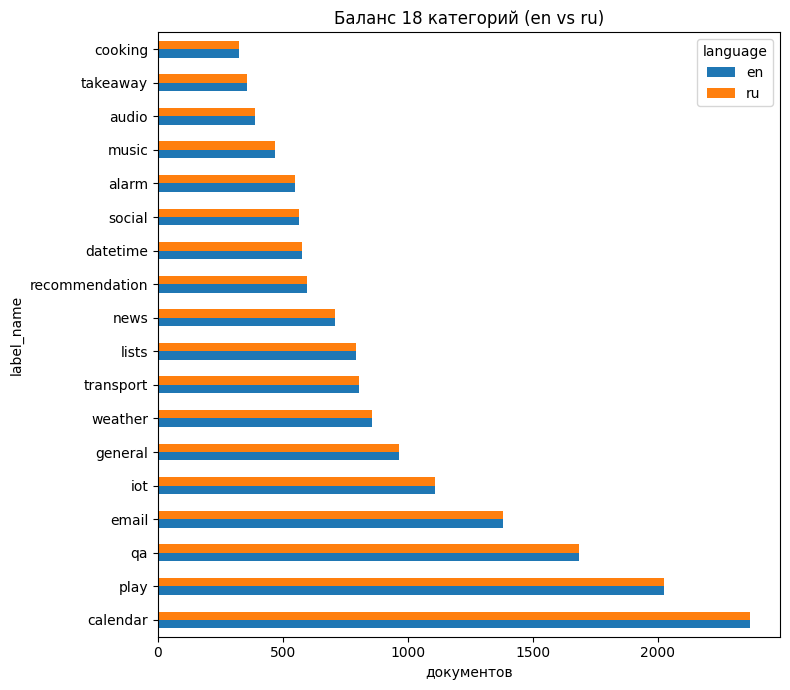


Длина текста (слов):
mean     6.380607
50%      6.000000
max     61.000000
Name: n_words, dtype: float64


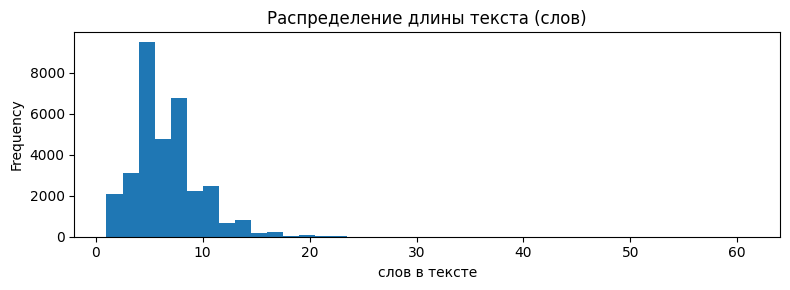


Пустых текстов: 0


In [8]:
import matplotlib.pyplot as plt

# --- 1. Баланс категорий (сравним en и ru) ---
counts = df.groupby(["label_name","language"]).size().unstack(fill_value=0)
counts = counts.sort_values("en", ascending=False)
print("Документов по категориям:\n", counts)

counts.plot(kind="barh", figsize=(8,7))
plt.title("Баланс 18 категорий (en vs ru)")
plt.xlabel("документов"); plt.tight_layout(); plt.show()

# --- 2. Длина текстов (в словах) ---
df["n_words"] = df["text"].str.split().str.len()
print("\nДлина текста (слов):")
print(df["n_words"].describe()[["mean","50%","max"]])

df["n_words"].plot(kind="hist", bins=40, figsize=(8,3))
plt.title("Распределение длины текста (слов)")
plt.xlabel("слов в тексте"); plt.tight_layout(); plt.show()

# --- 3. Пустые/битые тексты ---
print("\nПустых текстов:", (df["n_words"]==0).sum())

In [9]:
# по паре примеров из разных категорий
for cat in ["calendar", "news", "weather", "cooking"]:
    print(f"\n=== {cat} ===")
    sample = df[(df.language=="en") & (df.label_name==cat)]["text"].head(2).tolist()
    for t in sample:
        print(" •", t)


=== calendar ===
 • check when the show starts
 • please tell me current events for the day

=== news ===
 • what's happening in football today
 • tell me b. b. c. news

=== weather ===
 • is it raining
 • is it going to rain

=== cooking ===
 • what to cook for lunch
 • how long should i boil the eggs


## Этап 4 — Бейзлайн: TF-IDF + LogisticRegression

In [ ]:
# TODO (этап 4)

## Этап 5 — Дообучение DistilBERT (GPU / Colab)

In [ ]:
# TODO (этап 5)

## Этап 6 — Оценка и сравнение с бейзлайном
accuracy, F1-macro, матрица ошибок, per-language, обгон бейзлайна ≥5%.

In [ ]:
# TODO (этап 6): сохранить reports/performance_metrics.json